# Pit Stop Submission Blender: Super Anchor Search

This notebook builds a compact blending pipeline around the strongest available public submission. The previous blender reached a stable `0.95410` region, but the new `0.95418` file changes the search strategy: it should become the main anchor, while other submissions should only make small, controlled corrections.

The output is intentionally simple. The strongest candidates are saved to `outputs/max`, secondary candidates are saved to `outputs/pro`, and the whole submit order is summarized in one file: `outputs/report.csv`.


In [1]:
"""Import libraries, configure paths, and define compact notebook display helpers."""

from pathlib import Path
from html import escape
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
from IPython.display import display, HTML

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")

ID_COL = "id"
TARGET_COL = "PitNextLap"
CLIP_LOW = 1e-7
CLIP_HIGH = 1 - 1e-7

DATASET_CANDIDATES = [
    Path("/kaggle/input/pitstop-blend-inputs"),
    Path("/kaggle/input/pit-stop-blend-inputs"),
    Path("/kaggle/input/blend-dataset"),
    Path("/kaggle/input") / "blend_dataset",
    Path("PredictingPitStop/blend_dataset"),
    Path("blend_dataset"),
]

OUTPUT_ROOT = Path("outputs")
MAX_ROOT = OUTPUT_ROOT / "max"
PRO_ROOT = OUTPUT_ROOT / "pro"
REPORT_PATH = OUTPUT_ROOT / "report.csv"
DIAGNOSTIC_ROOT = OUTPUT_ROOT / "diagnostics"

# Keep the Kaggle output clean: this notebook writes two submission folders and one main report.
for folder in [MAX_ROOT, PRO_ROOT, DIAGNOSTIC_ROOT]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)
if REPORT_PATH.exists():
    REPORT_PATH.unlink()


def find_dataset_dir():
    for path in DATASET_CANDIDATES:
        if (path / "public").exists() and (path / "ours").exists():
            return path
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in sorted(kaggle_input.rglob("*")):
            if path.is_dir() and (path / "public").exists() and (path / "ours").exists():
                return path
    raise FileNotFoundError("Could not find a dataset folder containing public/ and ours/ subfolders.")


def show_title(title, subtitle=None):
    subtitle_html = f'<div style="color:#6b7280;font-size:13px;margin-top:4px;">{escape(str(subtitle))}</div>' if subtitle else ""
    display(HTML(
        f"""
        <div style="margin:20px 0 12px 0;padding-bottom:9px;border-bottom:1px solid #e5e7eb;">
          <div style="font-size:20px;font-weight:750;color:#111827;">{escape(str(title))}</div>
          {subtitle_html}
        </div>
        """
    ))


def show_cards(metrics, columns=4):
    width = max(1, int(100 / columns))
    cards = []
    for label, value in metrics.items():
        if isinstance(value, float):
            value = f"{value:.6f}".rstrip("0").rstrip(".")
        elif isinstance(value, int):
            value = f"{value:,}"
        cards.append(
            f"""
            <div style="box-sizing:border-box;width:{width}%;padding:6px;">
              <div style="border:1px solid #e5e7eb;border-radius:8px;padding:12px;background:#fff;">
                <div style="font-size:12px;color:#6b7280;text-transform:uppercase;letter-spacing:.03em;">{escape(str(label))}</div>
                <div style="font-size:21px;font-weight:750;color:#111827;margin-top:5px;">{escape(str(value))}</div>
              </div>
            </div>
            """
        )
    display(HTML(f'<div style="display:flex;flex-wrap:wrap;margin:0 -6px 14px -6px;">{"".join(cards)}</div>'))


def show_table(title, df, max_rows=12, precision=6):
    shown = df.head(max_rows).copy()
    display(HTML(f'<div style="font-size:16px;font-weight:700;color:#111827;margin:14px 0 6px;">{escape(title)}</div>'))
    styler = shown.style.format(precision=precision).set_table_styles([
        {"selector":"th", "props":[("background", "#f9fafb"), ("color", "#374151"), ("font-weight", "700"), ("border-bottom", "1px solid #e5e7eb")]},
        {"selector":"td", "props":[("border-bottom", "1px solid #f3f4f6"), ("font-size", "13px")]},
        {"selector":"table", "props":[("border-collapse", "collapse"), ("width", "100%")]},
    ])
    display(styler)
    if len(df) > max_rows:
        display(HTML(f'<div style="color:#6b7280;font-size:12px;margin-top:4px;">Showing {max_rows} of {len(df)} rows.</div>'))


def mean_abs_delta(a, b):
    return float(np.abs(np.asarray(a) - np.asarray(b)).mean())


def corr(a, b):
    return float(np.corrcoef(np.asarray(a), np.asarray(b))[0, 1])


## 1. Load Structured Dataset

The dataset is read from the structured `blend_dataset` folder. The new `public/super` group contains the strongest files and drives the final candidates. Older public files and our own CatBoost outputs are kept for diagnostics and small stabilizing corrections only.


In [2]:
"""Load all valid submission files and keep their source, group, score, and prediction vector."""

dataset_dir = find_dataset_dir()

predictions = {}
records = []
base_ids = None


def load_submission(path, source):
    global base_ids
    df = pd.read_csv(path)
    if ID_COL not in df.columns:
        return None
    target_candidates = [col for col in df.columns if col != ID_COL]
    if TARGET_COL in df.columns:
        target_col = TARGET_COL
    elif len(target_candidates) == 1:
        target_col = target_candidates[0]
    else:
        return None

    df = df[[ID_COL, target_col]].rename(columns={target_col: TARGET_COL})
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    if df[TARGET_COL].isna().any() or df[ID_COL].duplicated().any():
        return None

    if base_ids is None:
        base_ids = df[ID_COL].copy()
    elif not base_ids.equals(df[ID_COL]):
        return None

    group = path.parent.name
    safe_stem = path.stem.replace(".", "_").replace("-", "_")
    name = f"{source}_{group}_{safe_stem}"
    pred = np.clip(df[TARGET_COL].to_numpy(dtype=float), CLIP_LOW, CLIP_HIGH)
    predictions[name] = pred

    public_score = np.nan
    if source == "public":
        try:
            public_score = float(path.stem.split("_")[0])
        except ValueError:
            public_score = np.nan

    return {
        "name": name,
        "source": source,
        "group": group,
        "public_score": public_score,
        "rows": len(df),
        "mean": pred.mean(),
        "std": pred.std(),
        "file": str(path.relative_to(dataset_dir)),
    }


for source in ["public", "ours"]:
    folder = dataset_dir / source
    if folder.exists():
        for path in sorted(folder.rglob("*.csv")):
            row = load_submission(path, source)
            if row is not None:
                records.append(row)

if not records:
    raise FileNotFoundError("No valid submissions were loaded from the structured dataset.")

input_summary = pd.DataFrame(records).sort_values(
    ["source", "group", "public_score", "name"], ascending=[True, True, False, True]
).reset_index(drop=True)
input_summary.to_csv(DIAGNOSTIC_ROOT / "inputs.csv", index=False)

show_title("Loaded blend dataset", f"Dataset folder: {dataset_dir}")
show_cards({
    "input files": len(input_summary),
    "public files": int(input_summary["source"].eq("public").sum()),
    "own files": int(input_summary["source"].eq("ours").sum()),
    "rows": len(base_ids),
})
show_table(
    "Structured inputs",
    input_summary[["name", "source", "group", "public_score", "mean", "std", "file"]],
    max_rows=20,
)


,name,source,group,public_score,mean,std,file
0,ours_main_base,ours,main,nan,0.276797,0.361970,ours/main/base.csv
1,ours_main_prob,ours,main,nan,0.276541,0.362038,ours/main/prob.csv
2,ours_main_s42,ours,main,nan,0.276623,0.362434,ours/main/s42.csv
3,ours_main_s777,ours,main,nan,0.276787,0.361862,ours/main/s777.csv
4,ours_variants_reg,ours,variants,nan,0.279956,0.362559,ours/variants/reg.csv
5,ours_variants_shallow,ours,variants,nan,0.285043,0.364456,ours/variants/shallow.csv
6,public_core_0_95405,public,core,0.954050,0.219467,0.316353,public/core/0.95405.csv
7,public_core_0_95404,public,core,0.954040,0.222861,0.318378,public/core/0.95404.csv
8,public_core_0_95402,public,core,0.954020,0.226254,0.320474,public/core/0.95402.csv
9,public_core_0_95401,public,core,0.954010,0.213334,0.312760,public/core/0.95401.csv


## 2. Validate Super Inputs

The new high-scoring files are not all equally useful. The two `0.95411` files are very close to each other, while `0.95418` is different enough to become the new anchor. This block checks that relationship before we create blends.


,file,corr_to_95418,mean_abs_delta_to_95418,mean,std
0,public_super_0_95411_a,0.999513,0.007310,0.210557,0.309882
1,public_super_0_95411_b,0.999539,0.006628,0.209725,0.309808


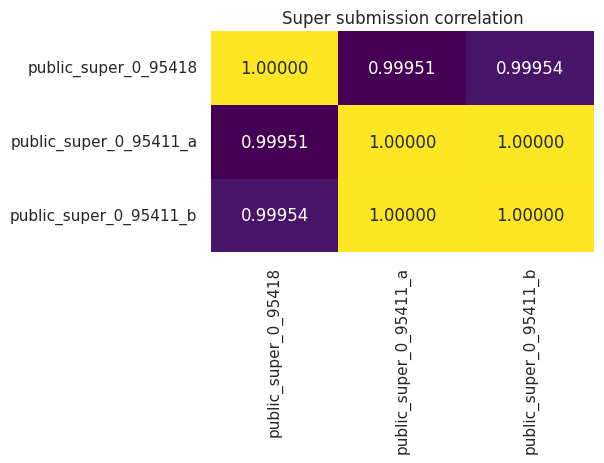

In [3]:
"""Select the super-anchor files and compare their similarity before blending."""

super_names = input_summary[input_summary["group"].eq("super")].sort_values("public_score", ascending=False)["name"].tolist()
if not super_names:
    raise RuntimeError("No files found in public/super. Add 0.95418 and 0.95411 submissions to the dataset first.")

anchor_names = input_summary[
    input_summary["group"].eq("super") & np.isclose(input_summary["public_score"], 0.95418, atol=1e-8)
]["name"].tolist()
if not anchor_names:
    raise RuntimeError("The 0.95418 super-anchor file is required.")
anchor_name = anchor_names[0]

support_95411 = input_summary[
    input_summary["group"].eq("super") & np.isclose(input_summary["public_score"], 0.95411, atol=1e-8)
]["name"].tolist()
if not support_95411:
    raise RuntimeError("At least one 0.95411 support file is required.")

super_matrix = pd.DataFrame({name: predictions[name] for name in super_names})
super_corr = super_matrix.corr()
super_delta_rows = []
for name in super_names:
    if name == anchor_name:
        continue
    super_delta_rows.append({
        "file": name,
        "corr_to_95418": corr(predictions[name], predictions[anchor_name]),
        "mean_abs_delta_to_95418": mean_abs_delta(predictions[name], predictions[anchor_name]),
        "mean": predictions[name].mean(),
        "std": predictions[name].std(),
    })
super_delta = pd.DataFrame(super_delta_rows).sort_values("mean_abs_delta_to_95418", ascending=False)
super_delta.to_csv(DIAGNOSTIC_ROOT / "super_similarity.csv", index=False)

show_title("Super-anchor diagnostics", "0.95418 is the main anchor; 0.95411 files are support signals")
show_cards({
    "super files": len(super_names),
    "anchor": "0.95418",
    "support files": len(support_95411),
    "anchor mean": predictions[anchor_name].mean(),
})
show_table("Distance from 0.95418", super_delta, max_rows=8)

fig, ax = plt.subplots(figsize=(6.2, 4.8))
if sns is not None:
    sns.heatmap(super_corr, cmap="viridis", annot=True, fmt=".5f", cbar=False, ax=ax)
else:
    im = ax.imshow(super_corr.values, cmap="viridis")
    ax.set_xticks(range(len(super_corr.columns)), super_corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(super_corr.index)), super_corr.index)
    fig.colorbar(im, ax=ax)
ax.set_title("Super submission correlation")
plt.tight_layout()
plt.show()


## 3. Build Reference Signals

We still keep the previous blender logic as reference signals, but they are no longer saved as standalone submissions. `b10` represents the old public-core recipe, `tx` represents the older `0.95409` external pair, and `tb` is the previous best local blend around `0.95410`.


In [4]:
"""Build old reference predictions in memory without saving extra submission files."""


def names_by_group(group):
    return input_summary[input_summary["group"].eq(group)]["name"].tolist()


def mean_predictions(names):
    if not names:
        raise RuntimeError("Cannot average an empty list of predictions.")
    return np.clip(np.vstack([predictions[name] for name in names]).mean(axis=0), CLIP_LOW, CLIP_HIGH)


def score_name(score, group=None):
    mask = input_summary["source"].eq("public") & np.isclose(input_summary["public_score"], score, atol=1e-8)
    if group is not None:
        mask = mask & input_summary["group"].eq(group)
    names = input_summary[mask]["name"].tolist()
    return names[0] if names else None


public_core = input_summary[input_summary["group"].eq("core")].sort_values("public_score", ascending=False)["name"].head(6).tolist()
public_diverse = names_by_group("diverse") or ([score_name(0.95381)] if score_name(0.95381) else [])
top_external = names_by_group("top_external")

if not public_core:
    raise RuntimeError("public/core is empty; cannot build old b10 reference.")
if not public_diverse:
    raise RuntimeError("public/diverse is empty; cannot build old b10 reference.")

core_pred = mean_predictions(public_core)
diverse_pred = predictions[public_diverse[0]]
b10_pred = np.clip(0.950 * core_pred + 0.050 * diverse_pred, CLIP_LOW, CLIP_HIGH)

if top_external:
    tx_pred = mean_predictions(top_external)
    tb_pred = np.clip(0.900 * tx_pred + 0.100 * b10_pred, CLIP_LOW, CLIP_HIGH)
else:
    tx_pred = None
    tb_pred = b10_pred

s18_pred = predictions[anchor_name]
s11_pred = mean_predictions(support_95411)

reference_rows = [
    {"signal": "s18", "role": "new strongest anchor", "mean": s18_pred.mean(), "std": s18_pred.std(), "corr_to_s18": 1.0, "delta_to_s18": 0.0},
    {"signal": "s11", "role": "mean of non-duplicate 0.95411 support files", "mean": s11_pred.mean(), "std": s11_pred.std(), "corr_to_s18": corr(s11_pred, s18_pred), "delta_to_s18": mean_abs_delta(s11_pred, s18_pred)},
    {"signal": "b10", "role": "old public-core baseline", "mean": b10_pred.mean(), "std": b10_pred.std(), "corr_to_s18": corr(b10_pred, s18_pred), "delta_to_s18": mean_abs_delta(b10_pred, s18_pred)},
    {"signal": "tb", "role": "previous best 0.95410 blend", "mean": tb_pred.mean(), "std": tb_pred.std(), "corr_to_s18": corr(tb_pred, s18_pred), "delta_to_s18": mean_abs_delta(tb_pred, s18_pred)},
]
reference_summary = pd.DataFrame(reference_rows)
reference_summary.to_csv(DIAGNOSTIC_ROOT / "reference_signals.csv", index=False)

show_title("Reference signals", "Old blends are calculated only as small correction sources")
show_table("Reference summary", reference_summary, max_rows=len(reference_summary))


,signal,role,mean,std,corr_to_s18,delta_to_s18
0,s18,new strongest anchor,0.203916,0.306700,1.000000,0.000000
1,s11,mean of non-duplicate 0.95411 support files,0.210141,0.309845,0.999526,0.006964
2,b10,old public-core baseline,0.233012,0.312425,0.997066,0.029266
3,tb,previous best 0.95410 blend,0.209844,0.309904,0.999532,0.006708


## 4. Create Final Candidates

The search is intentionally narrow. `outputs/max` contains the three candidates that should be submitted first, ordered by priority. `outputs/pro` contains two secondary candidates that move slightly further from the `0.95418` anchor and should be used only if there are enough attempts.


In [5]:
"""Create and save only the most important super-anchor submission candidates."""


def save_submission(path, pred):
    pred = np.clip(pred, CLIP_LOW, CLIP_HIGH)
    pd.DataFrame({ID_COL: base_ids.values, TARGET_COL: pred}).to_csv(path, index=False)

candidate_specs = [
    {
        "key": "s18",
        "tier": "max",
        "formula": "0.95418 raw anchor",
        "reason": "Submit the strongest new file unchanged.",
        "pred": s18_pred,
        "priority": 1,
    },
    {
        "key": "sx95",
        "tier": "max",
        "formula": "0.950*s18 + 0.050*s11",
        "reason": "Tiny correction from the 0.95411 cluster.",
        "pred": 0.950 * s18_pred + 0.050 * s11_pred,
        "priority": 2,
    },
    {
        "key": "sb95",
        "tier": "max",
        "formula": "0.950*s18 + 0.050*tb",
        "reason": "Tiny correction from the previous 0.95410 blend.",
        "pred": 0.950 * s18_pred + 0.050 * tb_pred,
        "priority": 3,
    },
    {
        "key": "sc90",
        "tier": "pro",
        "formula": "0.900*s18 + 0.050*s11 + 0.050*tb",
        "reason": "Balanced conservative test with both support signals.",
        "pred": 0.900 * s18_pred + 0.050 * s11_pred + 0.050 * tb_pred,
        "priority": 4,
    },
    {
        "key": "sx90",
        "tier": "pro",
        "formula": "0.900*s18 + 0.100*s11",
        "reason": "Slightly stronger test of the 0.95411 correction.",
        "pred": 0.900 * s18_pred + 0.100 * s11_pred,
        "priority": 5,
    },
]

candidate_rows = []
for spec in candidate_specs:
    pred = np.clip(spec["pred"], CLIP_LOW, CLIP_HIGH)
    output_dir = MAX_ROOT if spec["tier"] == "max" else PRO_ROOT
    file_path = output_dir / f"{spec['key']}.csv"
    save_submission(file_path, pred)
    candidate_rows.append({
        "priority": spec["priority"],
        "tier": spec["tier"],
        "candidate": spec["key"],
        "file": str(file_path.relative_to(OUTPUT_ROOT)),
        "formula": spec["formula"],
        "mean": pred.mean(),
        "std": pred.std(),
        "corr_to_s18": corr(pred, s18_pred),
        "delta_to_s18": mean_abs_delta(pred, s18_pred),
        "delta_to_s11": mean_abs_delta(pred, s11_pred),
        "delta_to_tb": mean_abs_delta(pred, tb_pred),
        "reason": spec["reason"],
    })

candidate_summary = pd.DataFrame(candidate_rows).sort_values("priority").reset_index(drop=True)
candidate_summary.to_csv(REPORT_PATH, index=False)

show_title("Saved final candidates", "Max contains the first submissions; pro contains secondary checks")
show_table(
    "Submission set",
    candidate_summary[["priority", "tier", "candidate", "file", "formula", "corr_to_s18", "delta_to_s18", "reason"]],
    max_rows=len(candidate_summary),
)


,priority,tier,candidate,file,formula,corr_to_s18,delta_to_s18,reason
0,1,max,s18,max/s18.csv,0.95418 raw anchor,1.000000,0.000000,Submit the strongest new file unchanged.
1,2,max,sx95,max/sx95.csv,0.950*s18 + 0.050*s11,0.999999,0.000348,Tiny correction from the 0.95411 cluster.
2,3,max,sb95,max/sb95.csv,0.950*s18 + 0.050*tb,0.999999,0.000335,Tiny correction from the previous 0.95410 blend.
3,4,pro,sc90,pro/sc90.csv,0.900*s18 + 0.050*s11 + 0.050*tb,0.999995,0.000683,Balanced conservative test with both support signals.
4,5,pro,sx90,pro/sx90.csv,0.900*s18 + 0.100*s11,0.999995,0.000696,Slightly stronger test of the 0.95411 correction.


## 5. Compare Candidate Movement

This section checks that the saved files are not accidental duplicates and are not moving too far away from the new anchor. For this stage, smaller movement is usually safer: we are trying to improve a strong `0.95418` submission, not replace it with a broad average.


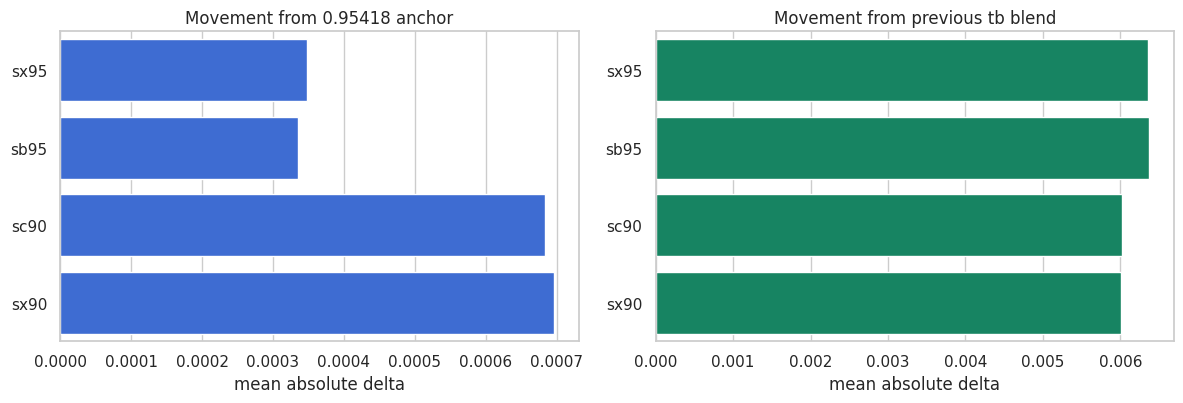

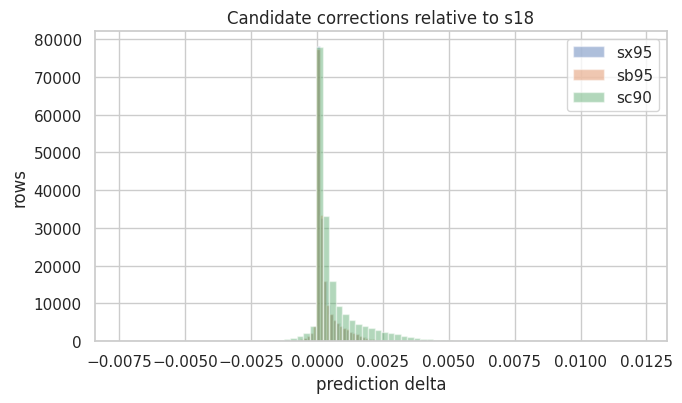

,priority,tier,candidate,file,formula,reason
0,1,max,s18,max/s18.csv,0.95418 raw anchor,Submit the strongest new file unchanged.
1,2,max,sx95,max/sx95.csv,0.950*s18 + 0.050*s11,Tiny correction from the 0.95411 cluster.
2,3,max,sb95,max/sb95.csv,0.950*s18 + 0.050*tb,Tiny correction from the previous 0.95410 blend.
3,4,pro,sc90,pro/sc90.csv,0.900*s18 + 0.050*s11 + 0.050*tb,Balanced conservative test with both support signals.
4,5,pro,sx90,pro/sx90.csv,0.900*s18 + 0.100*s11,Slightly stronger test of the 0.95411 correction.


In [6]:
"""Plot candidate movement and show the final submit order in a compact format."""

plot_df = candidate_summary[candidate_summary["candidate"].ne("s18")].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
if sns is not None:
    sns.barplot(data=plot_df, y="candidate", x="delta_to_s18", color="#2563eb", ax=axes[0])
    sns.barplot(data=plot_df, y="candidate", x="delta_to_tb", color="#059669", ax=axes[1])
else:
    axes[0].barh(plot_df["candidate"], plot_df["delta_to_s18"])
    axes[1].barh(plot_df["candidate"], plot_df["delta_to_tb"])
axes[0].set_title("Movement from 0.95418 anchor")
axes[1].set_title("Movement from previous tb blend")
for ax in axes:
    ax.set_xlabel("mean absolute delta")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.2))
for candidate in ["sx95", "sb95", "sc90"]:
    path = (MAX_ROOT if candidate in ["sx95", "sb95"] else PRO_ROOT) / f"{candidate}.csv"
    pred = pd.read_csv(path)[TARGET_COL].to_numpy()
    delta = pred - s18_pred
    ax.hist(delta, bins=80, alpha=0.45, label=candidate)
ax.set_title("Candidate corrections relative to s18")
ax.set_xlabel("prediction delta")
ax.set_ylabel("rows")
ax.legend()
plt.tight_layout()
plt.show()

submit_order = candidate_summary[["priority", "tier", "candidate", "file", "formula", "reason"]].copy()
show_title("Recommended submit order", "Upload max first; use pro only for extra attempts")
show_table("Final checklist", submit_order, max_rows=len(submit_order))


## Final Notes

The new blender is built around a single principle: keep `0.95418` as the anchor and test only small, readable corrections. Submit files from `outputs/max` first, in the order shown in `outputs/report.csv`. Use `outputs/pro` only after the max candidates are tested or if there are enough attempts.

The output structure is intentionally minimal: `outputs/max`, `outputs/pro`, `outputs/report.csv`, and a small `outputs/diagnostics` folder for notebook analysis.
